## Setup

In [34]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS, SPECIES_ALL,
                                 species_label, target_config)


def load(path):
    if not path.exists():
        raise SystemExit(f"missing: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)


TARGET     = "pion"          # "pion" | "photon"
COMPARISON = "architecture"        # "architecture" | "features"
cfg = target_config(TARGET)

MC_DIR   = PROJECT_ROOT / "predictions" / "predictions-mc"
DATA_DIR = PROJECT_ROOT / "predictions" / "predictions-data"
S = cfg['suffix']

if COMPARISON == "architecture":
    MODELS = [
        ("CNN",    MC_DIR / f"cnn_dEdX_seq{S}.pkl",         DATA_DIR / f"cnn_data_predictions{S}.pkl"),
        ("MLP",    MC_DIR / f"mlp_summary_base4{S}.pkl",    DATA_DIR / f"mlp_data_predictions{S}.pkl"),
        ("Hybrid", MC_DIR / f"hybrid_cnn_mlp_base4{S}.pkl", DATA_DIR / f"hybrid_data_predictions_base4{S}.pkl"),
    ]
    MODEL_COLOR = {"CNN": "steelblue", "MLP": "forestgreen", "Hybrid": "crimson"}
    SUBTITLE = "identical inputs: the four original summary features"
else:
    MODELS = [
        ("Hybrid base4", MC_DIR / f"hybrid_cnn_mlp_base4{S}.pkl",
                         DATA_DIR / f"hybrid_data_predictions_base4{S}.pkl"),
        ("Hybrid all8",  MC_DIR / f"hybrid_cnn_mlp_all8{S}.pkl",
                         DATA_DIR / f"hybrid_data_predictions_all8{S}.pkl"),
    ]
    MODEL_COLOR = {"Hybrid base4": "grey", "Hybrid all8": "crimson"}
    SUBTITLE = "same architecture, with and without the provenance features"

bins = np.linspace(0, 1, 41)
centres = 0.5 * (bins[:-1] + bins[1:])

TRACKS_PATH = PROJECT_ROOT / "prepared" / "prepared-mc" / "test_tracks.pkl"
with open(TRACKS_PATH, "rb") as f:
    tracks = pickle.load(f)
species   = np.array([species_label(t) for t in tracks])
is_signal = np.array([cfg['is_signal'](t) for t in tracks])

SPECIES = SPECIES_ALL
counts  = {sp: int((species == sp).sum()) for sp in SPECIES}

PLOTS_DIR = PROJECT_ROOT / "plots" / "data-mc-comparison" / TARGET
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"comparison: {COMPARISON} — {SUBTITLE}")
for name, mc_p, da_p in MODELS:
    print(f"  {name:<15} {'OK' if mc_p.exists() else 'MISSING MC':<12}"
          f"{'OK' if da_p.exists() else 'MISSING DATA'}")

comparison: architecture — identical inputs: the four original summary features
  CNN             OK          OK
  MLP             OK          OK
  Hybrid          OK          OK


## Data/MC classifier-score comparison

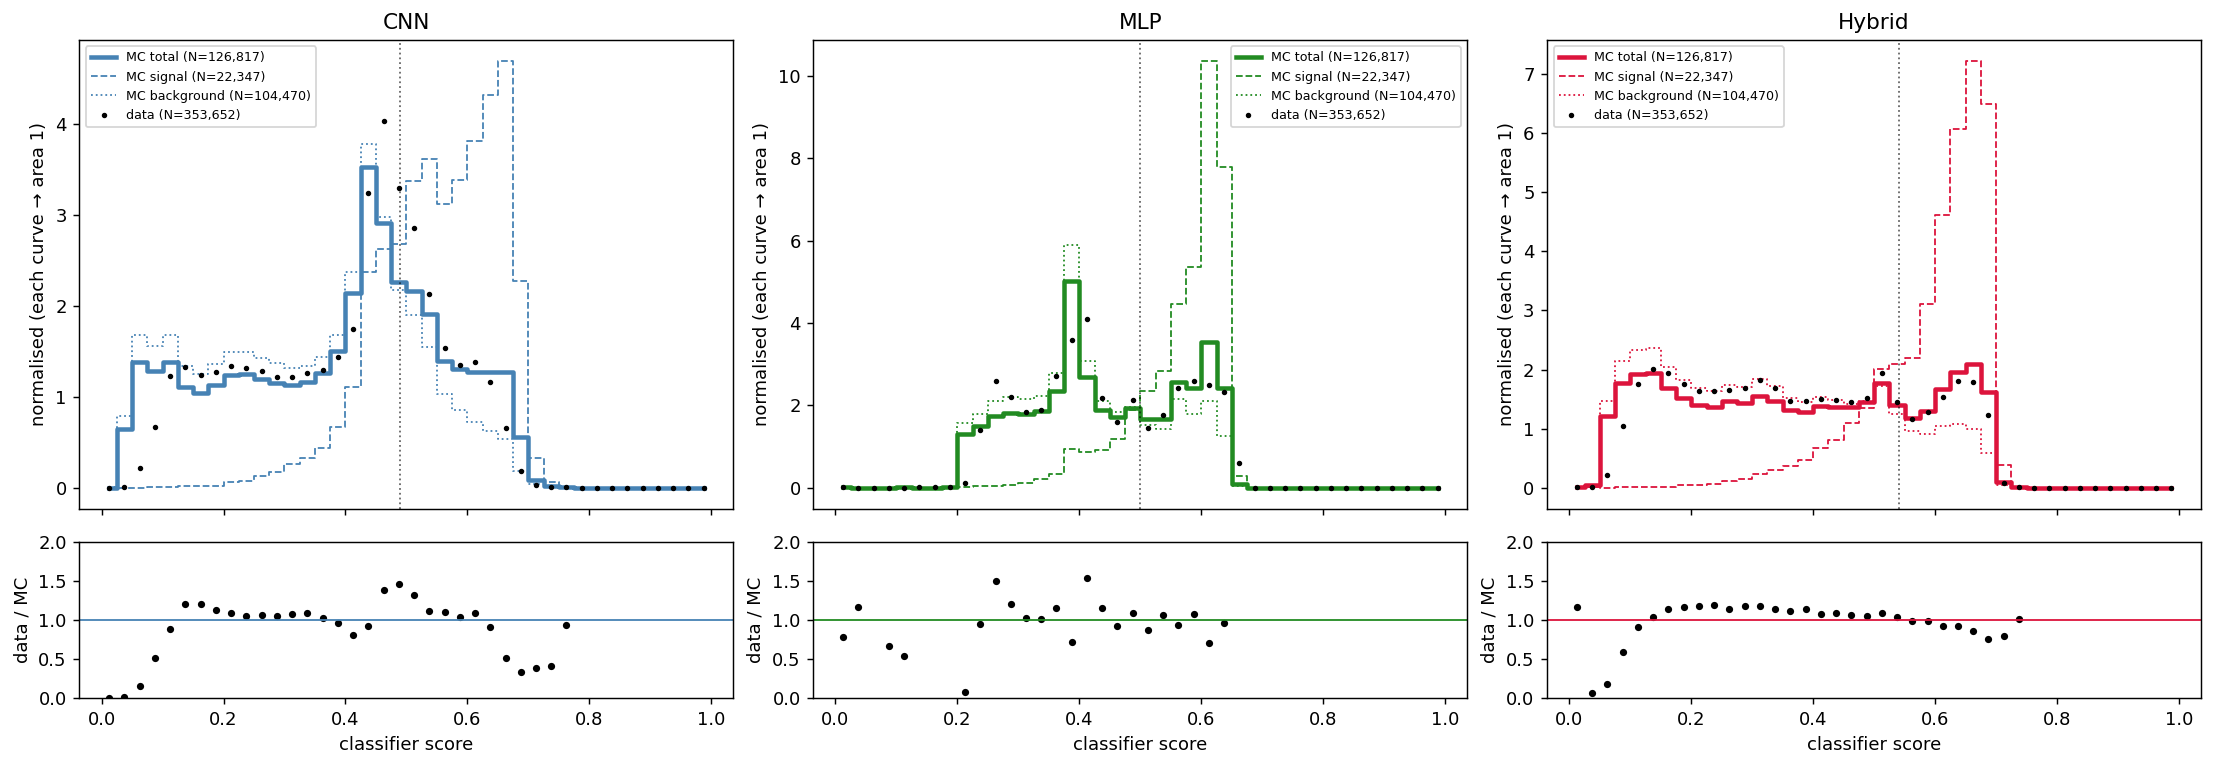

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/data_mc_total_comparison_architecture_pion.pdf


In [35]:
# =============================================================================
# DATA / MC CLASSIFIER-SCORE COMPARISON
#
# For each model (MLP, CNN, Hybrid) we overlay the classifier's output score on
# real DATA against the MC expectation, to check the classifier behaves the same
# on data as it does in simulation.
#
#   - MC total (bold line): all MC test PFOs (pions + non-pions in their true
#     proportion) -- this is the fair thing to compare data against, since data
#     is also an unlabelled mixture. Dashed curves show the pion/non-pion split
#     for context only.
#   - Data (black dots): all data PFOs. Data has no truth labels, so we can only
#     compare the overall SHAPE, not purity/efficiency.
#   - Bottom panels: data / MC-total ratio per score bin. Perfect agreement = all
#     dots on 1.0. Departures from 1.0 are real data/MC differences, and where
#     they sit (e.g. an excess in the mid-score region) tells us how the
#     disagreement is structured.
# =============================================================================

n_models = len(MODELS)

fig, ax = plt.subplots(2, n_models, figsize=(17, 6), dpi=130, gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
for k, (name, mc_path, data_path) in enumerate(MODELS):
    mc = load(mc_path); da = load(data_path)
    probs = np.asarray(mc["probs"]); labels = np.asarray(mc["labels"]).astype(int); thr = mc["threshold"]
    dprobs = np.asarray(da["probs"])
    Npi = int((labels == 1).sum()); Nnp = int((labels == 0).sum()); Nmc = len(probs); Nda = len(dprobs)

    tot, _ = np.histogram(probs, bins=bins, density=True)
    pi, _  = np.histogram(probs[labels == 1], bins=bins, density=True)
    npi, _ = np.histogram(probs[labels == 0], bins=bins, density=True)
    dat, _ = np.histogram(dprobs, bins=bins, density=True)

    a = ax[0, k]
    a.step(centres, tot, where="mid", color=MODEL_COLOR[name], lw=2.5, label=f"MC total (N={Nmc:,})")
    a.step(centres, pi, where="mid", color=MODEL_COLOR[name], lw=1, ls="--", label=f"MC signal (N={Npi:,})")
    a.step(centres, npi, where="mid", color=MODEL_COLOR[name], lw=1, ls=":", label=f"MC background (N={Nnp:,})")
    a.plot(centres, dat, "k.", ms=4, label=f"data (N={Nda:,})")
    a.axvline(thr, color="k", ls=":", lw=1, alpha=0.6); a.set_title(name)
    a.set_ylabel("normalised (each curve → area 1)"); a.legend(fontsize=7)

    r = np.divide(dat, tot, out=np.full_like(dat, np.nan), where=tot > 0)
    ax[1, k].plot(centres, r, "k."); ax[1, k].axhline(1, color=MODEL_COLOR[name], lw=1); ax[1, k].set_ylim(0, 2)
    ax[1, k].set_xlabel("classifier score"); ax[1, k].set_ylabel("data / MC")

plt.tight_layout()
out_path = PLOTS_DIR / f"data_mc_total_comparison_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Quantitative agreement (chi2/ndf, TVD)

In [17]:
# =============================================================================
# QUANTITATIVE DATA/MC AGREEMENT (classifier-score distributions, data vs MC total)
#   chi2/ndf : two-sample goodness-of-fit accounting for both samples' statistics.
#              ~1 = agree within stats; >>1 = statistically significant disagreement.
#   TVD      : total variation distance = 0.5*sum|p_data - p_mc|, range [0,1].
# =============================================================================

print(f"{'Model':<8}{'chi2/ndf':>10}{'TVD':>8}{'MC tag%':>11}{'Data tag%':>12}")
print("-" * 49)

for name, mc_path, data_path in MODELS:
    mc = load(mc_path); da = load(data_path)
    mc_probs, thr = mc["probs"], mc["threshold"]
    data_probs = da["probs"]

    m, _ = np.histogram(mc_probs, bins=bins)
    d, _ = np.histogram(data_probs, bins=bins)
    Nm, Nd = m.sum(), d.sum()
    p, q = d / Nd, m / Nm
    var = d / Nd**2 + m / Nm**2
    ok = var > 0
    chi2 = np.sum((p[ok] - q[ok])**2 / var[ok])
    ndf = ok.sum() - 1
    tvd = 0.5 * np.sum(np.abs(p - q))

    print(f"{name:<8}{chi2/ndf:>10.1f}{tvd:>8.3f}"
          f"{100*(mc_probs>=thr).mean():>10.1f}%{100*(data_probs>=thr).mean():>11.1f}%")

Model     chi2/ndf     TVD    MC tag%   Data tag%
-------------------------------------------------
CNN          348.2   0.112      30.2%       31.3%
MLP          427.1   0.109      35.9%       34.1%
Hybrid       154.9   0.074      26.1%       23.5%


## Species counts

In [18]:
# how many PFOs per species
for sp, n in Counter(species).most_common():
    print(f"{n:>7,}  {sp!r}")

 43,154  np.str_('$p$')
 22,347  np.str_('$\\pi^{\\pm}$')
 19,753  np.str_('$\\gamma$')
 13,679  np.str_('$\\mu^{\\pm}$')
 12,515  np.str_('$\\pi^{\\pm}$:2nd')
 10,190  np.str_('$\\gamma$:other')
  3,201  np.str_('$e^{+}$')
  1,978  np.str_('other')


## Per-species efficiency-at-threshold table

In [19]:
# per-species efficiency-at-threshold table
# (what fraction of each species lands above the pion threshold, MC only)
for name, mc_path, _ in MODELS:
    d = load(mc_path)
    probs = np.asarray(d["probs"]); thr = d["threshold"]
    tagged = probs >= thr
    ntag = tagged.sum()

    print(f"\n=== {name}  (threshold = {thr:.3f}) ===")
    print(f"{'species':<14}{'N':>8}{'median score':>14}{'% tagged':>15}{'% of tagged':>16}")

    for sp in SPECIES:
        m = species == sp
        med  = np.median(probs[m]) if m.sum() else np.nan
        leak = 100*np.mean(probs[m] >= thr) if m.sum() else 0
        comp = 100*np.sum(tagged & m)/ntag if ntag else 0
        print(f"{sp:<14}{m.sum():>8,}{med:>14.3f}{leak:>14.1f}%{comp:>15.1f}%")

    purity = 100*np.sum(tagged & is_signal)/ntag
    print(f"tagged sample: {ntag:,} PFOs   |   purity = {purity:.1f}%")


=== CNN  (threshold = 0.490) ===
species              N  median score       % tagged     % of tagged
$\pi^{\pm}$     22,347         0.566          75.2%           43.9%
$\pi^{\pm}$:2nd  12,515         0.523          61.3%           20.0%
$p$             43,154         0.192           7.2%            8.1%
$\gamma$        19,753         0.354           8.6%            4.5%
$\gamma$:other  10,190         0.397          10.1%            2.7%
$\mu^{\pm}$     13,679         0.495          52.3%           18.7%
$e^{+}$          3,201         0.436          18.1%            1.5%
other            1,978         0.309          11.0%            0.6%
tagged sample: 38,281 PFOs   |   purity = 43.9%

=== MLP  (threshold = 0.500) ===
species              N  median score       % tagged     % of tagged
$\pi^{\pm}$     22,347         0.594          83.5%           41.0%
$\pi^{\pm}$:2nd  12,515         0.565          69.7%           19.2%
$p$             43,154         0.345          17.9%           17.0

## Species breakdown, stacked, data overlay scaled

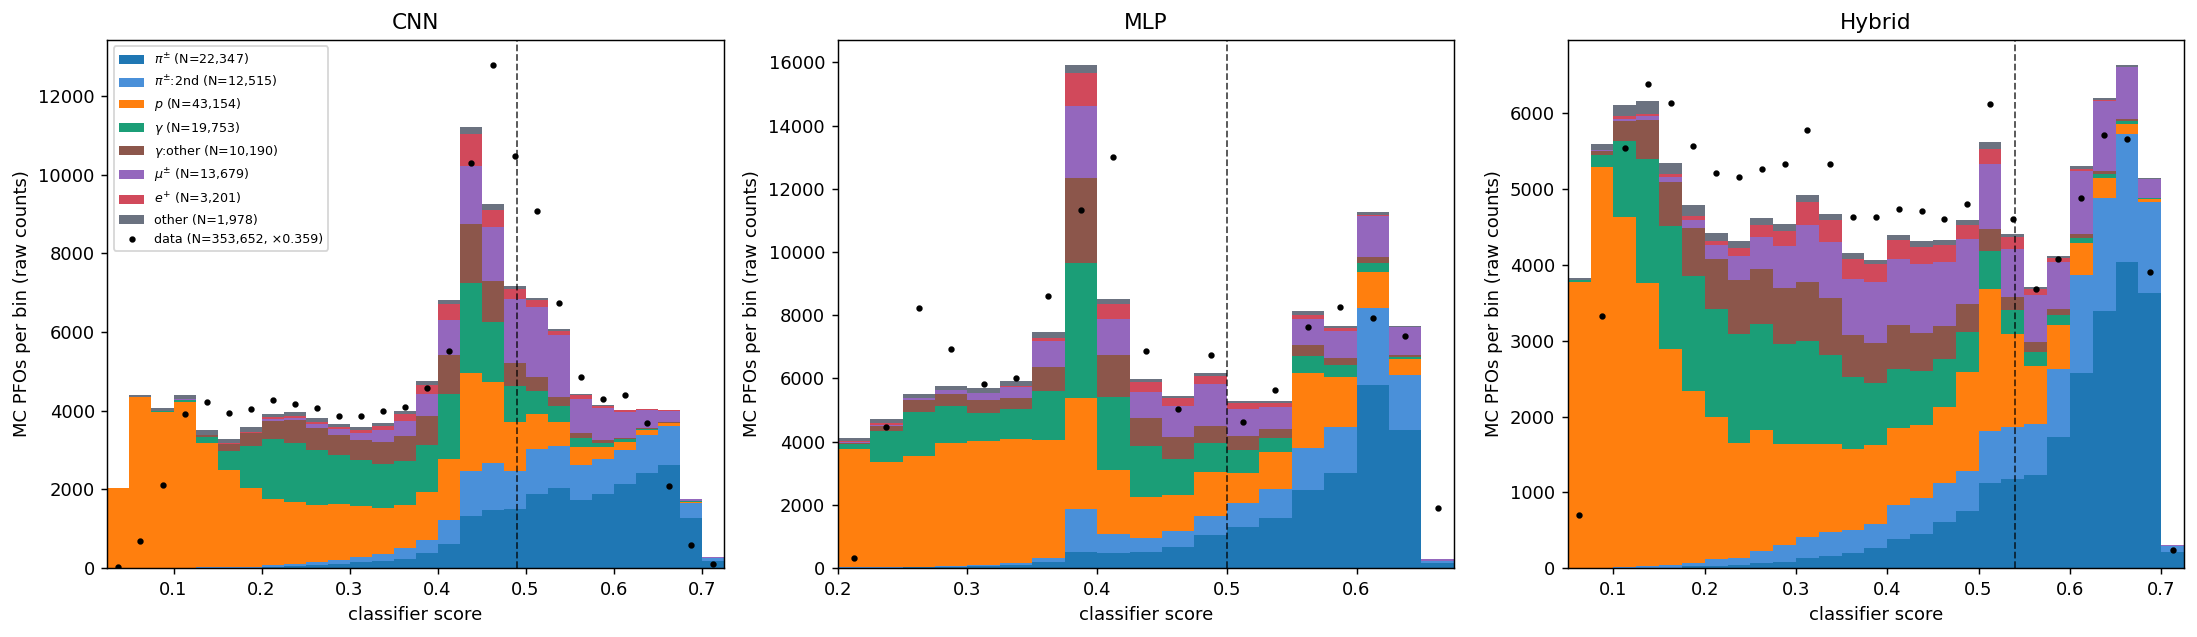

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/data_mc_by_species_architecture_pion.pdf


In [40]:
# Data/MC classifier score, MC broken down by TRUE species (raw counts, stacked)
fig, ax = plt.subplots(1, n_models, figsize=(17, 5), dpi=130)

for k, (name, mc_path, data_path) in enumerate(MODELS):
    mc = load(mc_path); da = load(data_path)
    probs = np.asarray(mc["probs"]); thr = mc["threshold"]; data_probs = np.asarray(da["probs"])
    Nmc = len(probs); Nda = len(data_probs); scale = Nmc / Nda

    arrs = [probs[species == s] for s in SPECIES]
    ax[k].hist(arrs, bins=bins, stacked=True, color=[SPECIES_COLORS[s] for s in SPECIES],
               label=[f"{s} (N={counts[s]:,})" for s in SPECIES], edgecolor='none')

    dh, _ = np.histogram(data_probs, bins=bins)
    ax[k].plot(centres, dh*scale, "k.", ms=5, label=f"data (N={Nda:,}, ×{scale:.3f})")
    ax[k].axvline(thr, color="k", ls="--", lw=1, alpha=0.7); ax[k].set_title(name)
    ax[k].set_xlabel("classifier score"); ax[k].set_ylabel("MC PFOs per bin (raw counts)")

    # clip to where MC has meaningful presence -- a bin needs at least 0.1% of
    # this model's MC sample (min 5) before it counts, so a lone stray point
    # doesn't drag the axis out to an empty-looking region
    mc_total, _ = np.histogram(probs, bins=bins)
    min_count = max(5, int(0.001 * Nmc))
    populated = np.where(mc_total >= min_count)[0]
    if len(populated):
        ax[k].set_xlim(bins[populated[0]], bins[populated[-1] + 1])

ax[0].legend(fontsize=7)
plt.tight_layout()
out_path = PLOTS_DIR / f"data_mc_by_species_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Same, not stacked

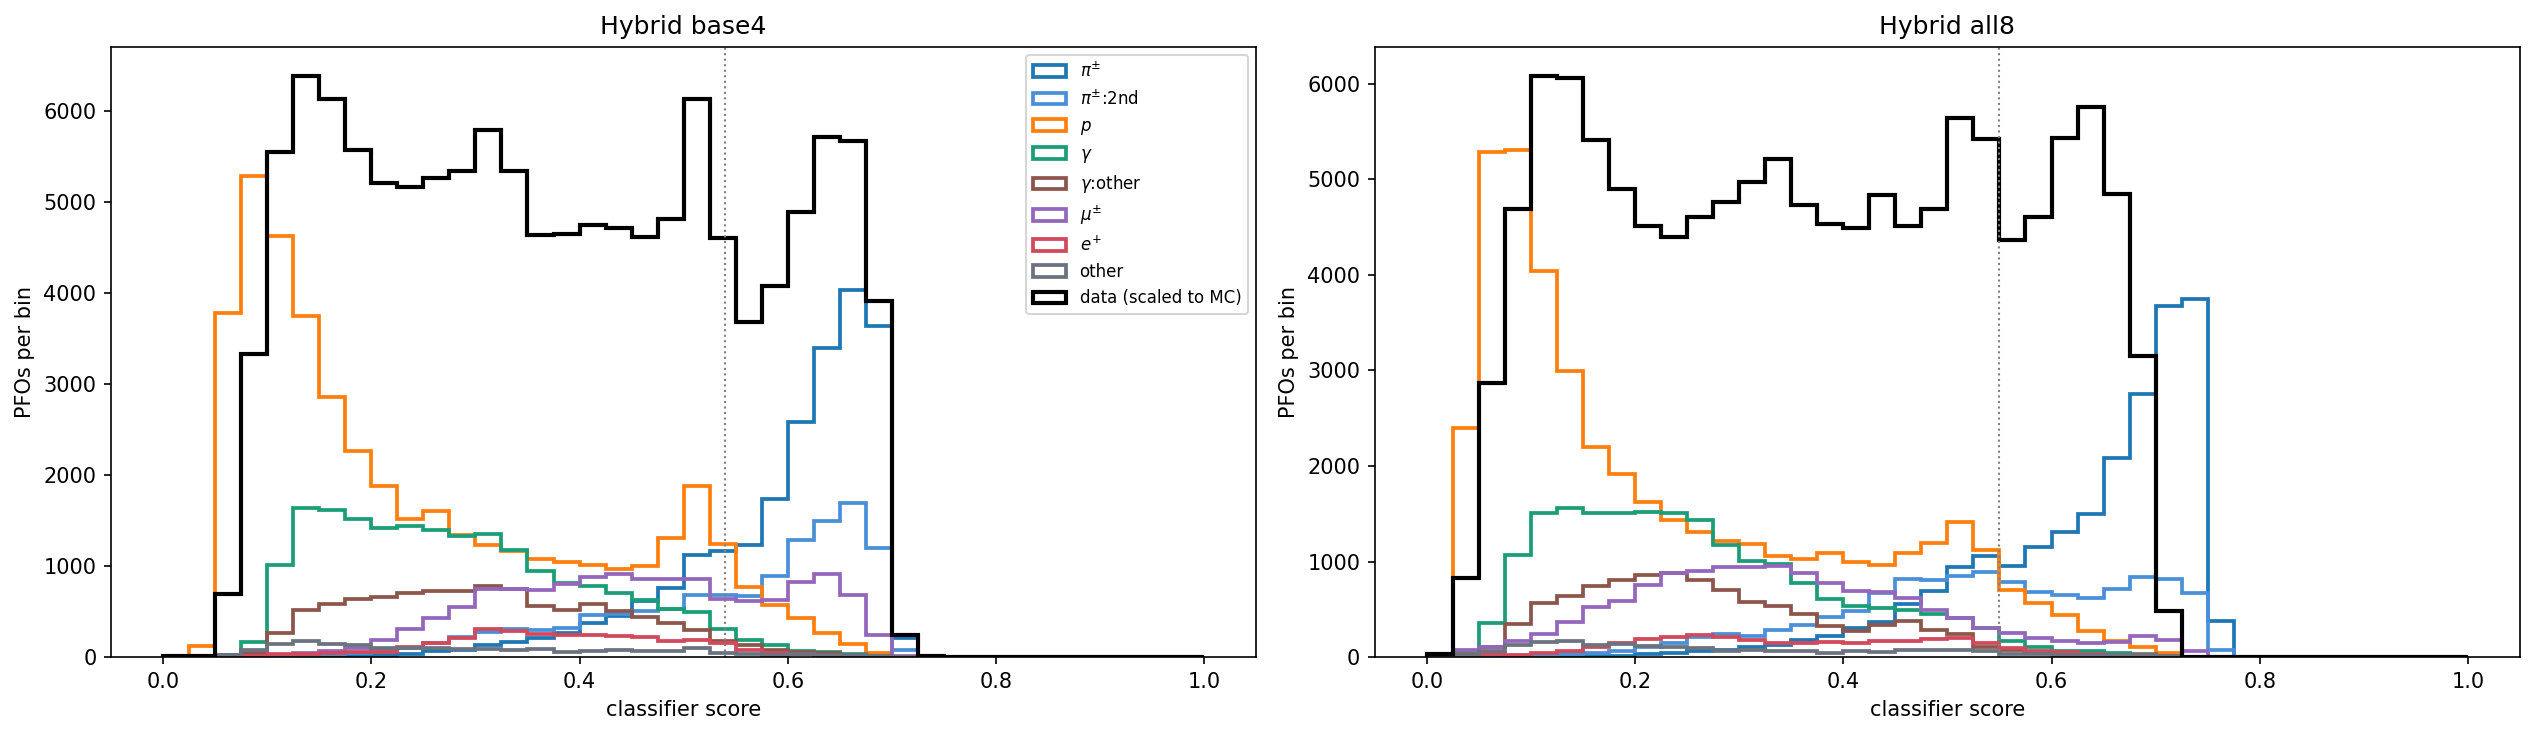

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/species_overlaid_features_pion.pdf


In [30]:
# same plot as above but not stacked
LOGY = False   # set True to reveal the rare species (e+, other)

fig, ax = plt.subplots(1, n_models, figsize=(17, 5), dpi=150)

for k, (name, mc_path, data_path) in enumerate(MODELS):
    mc = load(mc_path); da = load(data_path)
    probs = np.asarray(mc["probs"]); thr = da["threshold"]; data_probs = np.asarray(da["probs"])

    for sp in SPECIES:
        ax[k].hist(probs[species == sp], bins=bins, histtype='step', lw=1.8,
                   color=SPECIES_COLORS[sp], label=sp)

    scale = len(probs) / len(data_probs)
    ax[k].hist(data_probs, bins=bins, histtype='step', lw=2, color='k',
               weights=np.full(len(data_probs), scale), label='data (scaled to MC)')
    ax[k].axvline(thr, color='grey', ls=':', lw=1)
    ax[k].set_title(name); ax[k].set_xlabel('classifier score'); ax[k].set_ylabel('PFOs per bin')

    if LOGY:
        ax[k].set_yscale('log')

ax[0].legend(fontsize=8)
plt.tight_layout()
out_path = PLOTS_DIR / f"species_overlaid_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## MC-only species breakdown

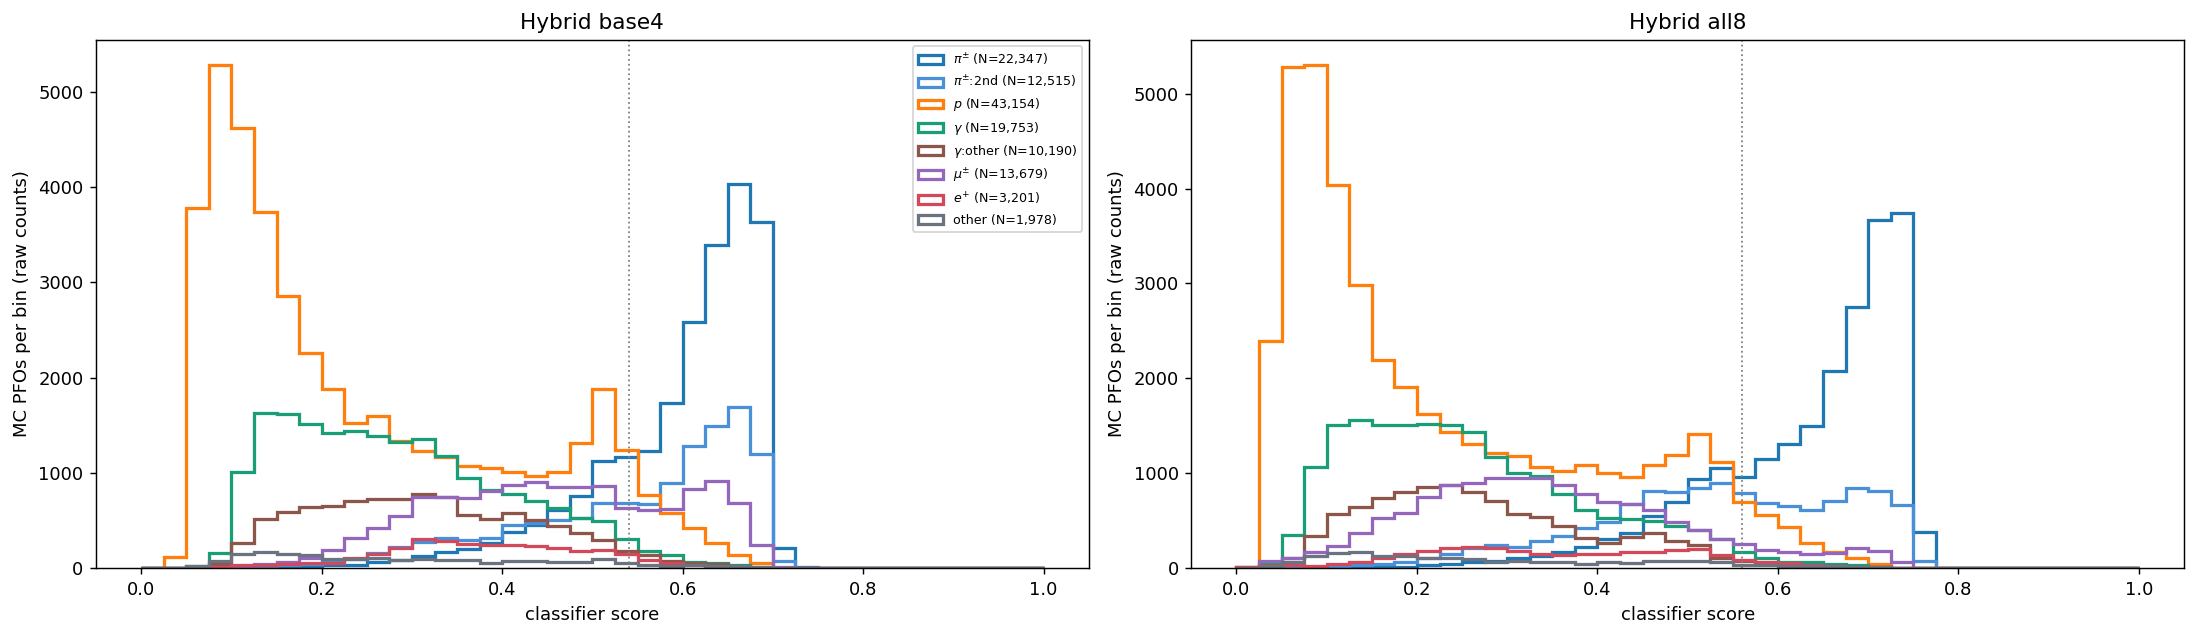

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/species_mc_only_features_pion.pdf


In [31]:
# MC only species breakdown
fig, ax = plt.subplots(1, n_models, figsize=(17, 5), dpi=130)

for k, (name, mc_path, _) in enumerate(MODELS):
    mc = load(mc_path); probs = np.asarray(mc["probs"]); thr = mc["threshold"]

    for sp in SPECIES:
        ax[k].hist(probs[species == sp], bins=bins, histtype='step', lw=1.8, color=SPECIES_COLORS[sp],
                   label=f"{sp} (N={counts[sp]:,})")

    ax[k].axvline(thr, color='grey', ls=':', lw=1); ax[k].set_title(name)
    ax[k].set_xlabel("classifier score"); ax[k].set_ylabel("MC PFOs per bin (raw counts)")

ax[0].legend(fontsize=7)
plt.tight_layout()
out_path = PLOTS_DIR / f"species_mc_only_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Area-normalised comparison

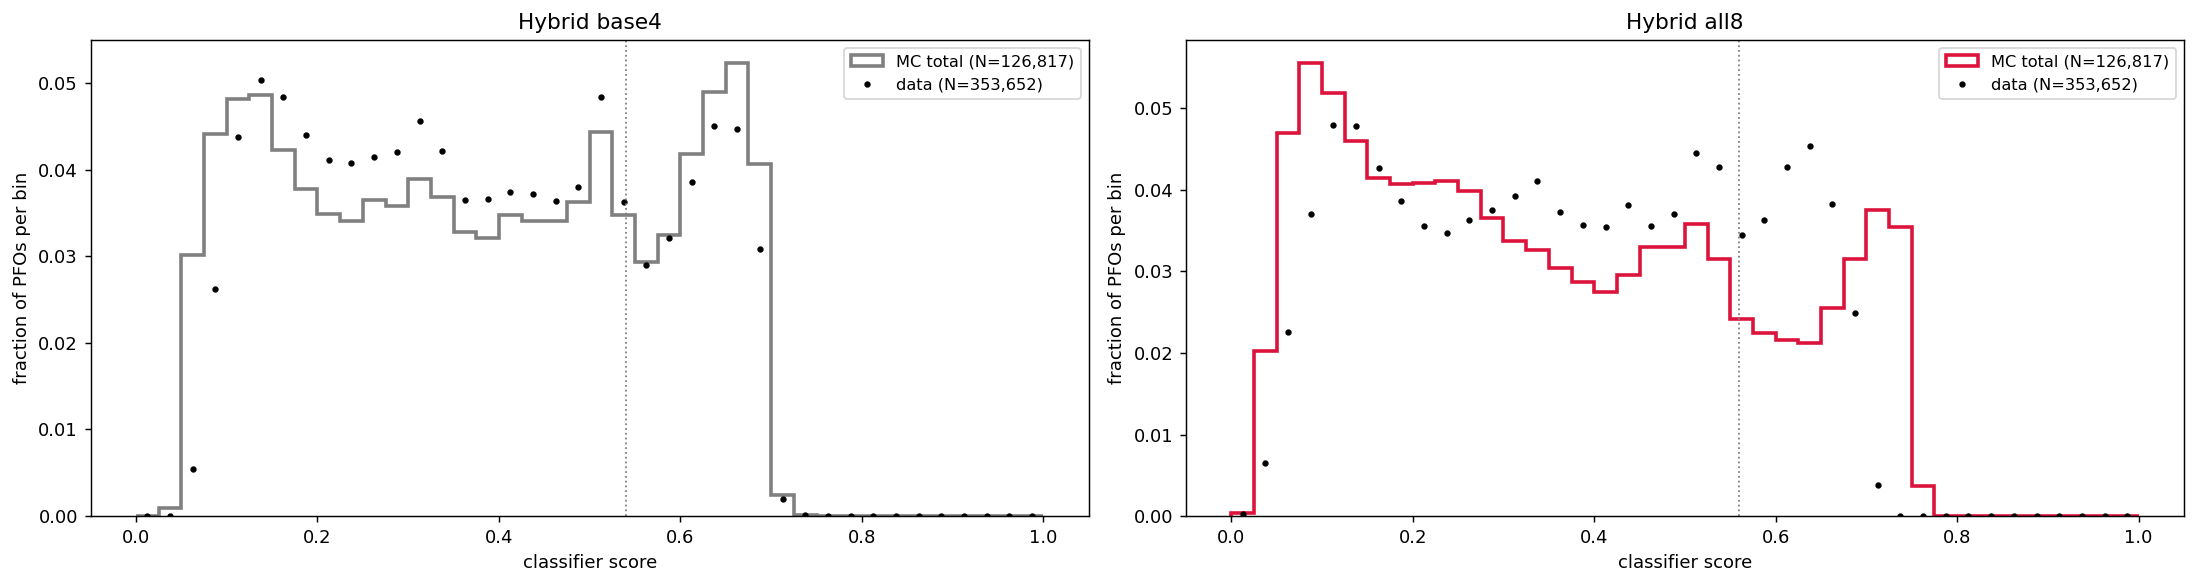

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/data_mc_areanorm_features_pion.pdf


In [32]:
# data vs MC total, area-normalised
fig, ax = plt.subplots(1, n_models, figsize=(17, 4.6), dpi=130)

for k, (name, mc_path, data_path) in enumerate(MODELS):
    mc = load(mc_path); da = load(data_path)
    probs = np.asarray(mc["probs"]); thr = mc["threshold"]; data_probs = np.asarray(da["probs"])
    Nmc, Nda = len(probs), len(data_probs)

    ax[k].hist(probs, bins=bins, weights=np.full(Nmc, 1/Nmc), histtype='step', lw=2,
               color=MODEL_COLOR[name], label=f"MC total (N={Nmc:,})")

    dh, _ = np.histogram(data_probs, bins=bins, weights=np.full(Nda, 1/Nda))
    ax[k].plot(centres, dh, 'k.', ms=5, label=f"data (N={Nda:,})")
    ax[k].axvline(thr, color='grey', ls=':', lw=1)
    ax[k].set_title(name); ax[k].set_xlabel('classifier score')
    ax[k].set_ylabel('fraction of PFOs per bin')
    ax[k].legend(fontsize=9)

plt.tight_layout()
out_path = PLOTS_DIR / f"data_mc_areanorm_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Twin-axis comparison

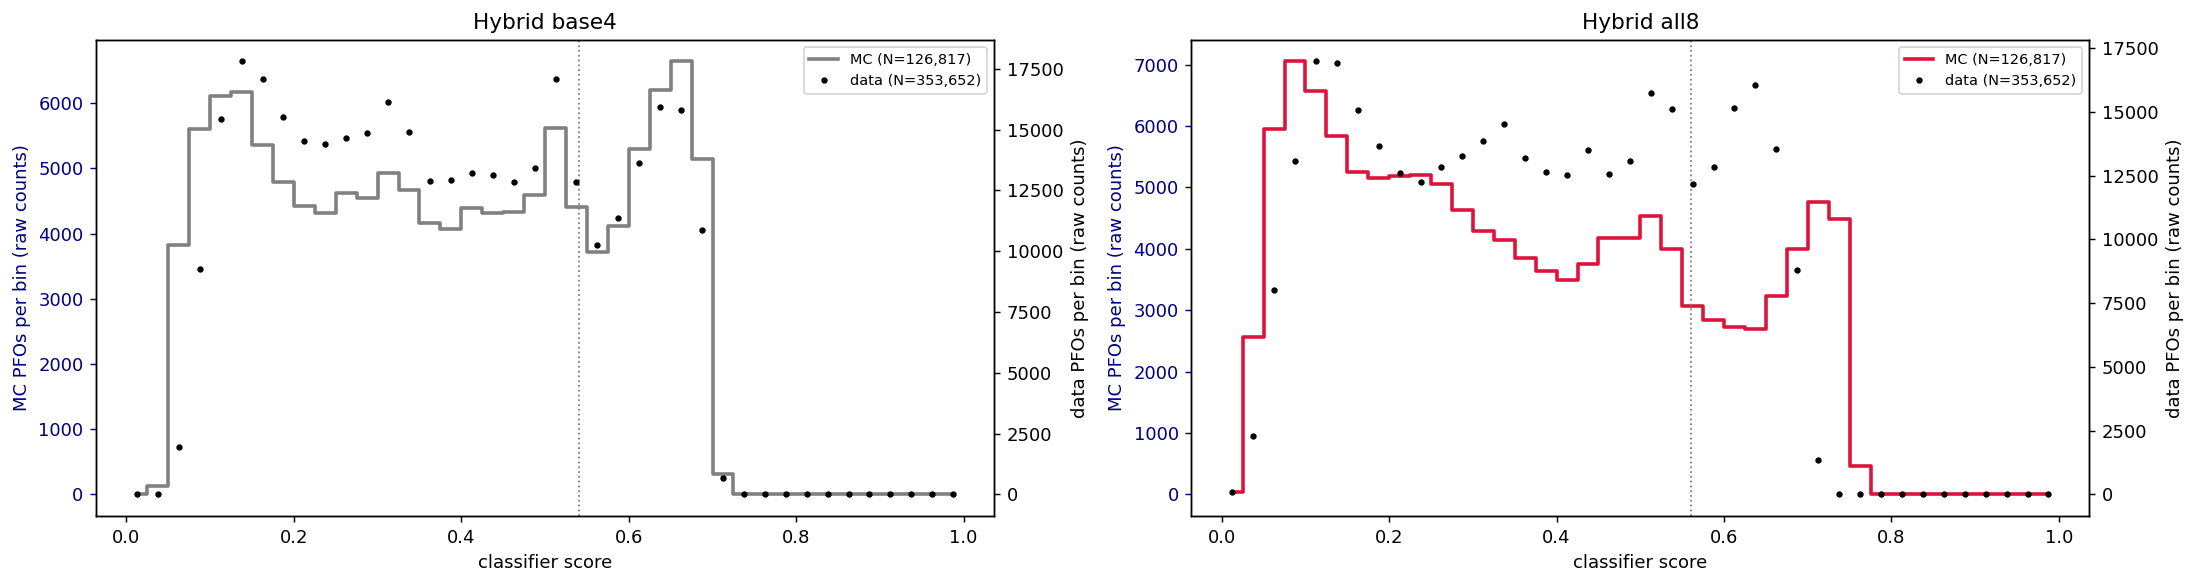

Saved /home/pemb7173/PDSP-pion-classification/plots/data-mc-comparison/pion/data_mc_twinaxis_features_pion.pdf


In [33]:
# data vs MC total, twin y-axis (both raw counts, each on its own scale)
fig, ax = plt.subplots(1, n_models, figsize=(17, 4.6), dpi=130)

for k, (name, mc_path, data_path) in enumerate(MODELS):
    mc = load(mc_path); da = load(data_path)
    probs = np.asarray(mc["probs"]); thr = mc["threshold"]; dprobs = np.asarray(da["probs"])
    Nmc = len(probs); Nda = len(dprobs)
    mc_h, _ = np.histogram(probs, bins=bins); d_h, _ = np.histogram(dprobs, bins=bins)

    axL = ax[k]; axR = axL.twinx()
    axL.step(centres, mc_h, where='mid', color=MODEL_COLOR[name], lw=2, label=f"MC (N={Nmc:,})")
    axR.plot(centres, d_h, 'k.', ms=5, label=f"data (N={Nda:,})")
    axL.axvline(thr, color='grey', ls=':', lw=1); axL.set_title(name); axL.set_xlabel("classifier score")
    axL.set_ylabel("MC PFOs per bin (raw counts)", color='navy'); axR.set_ylabel("data PFOs per bin (raw counts)")
    axL.tick_params(axis='y', colors='navy')
    l1, lab1 = axL.get_legend_handles_labels(); l2, lab2 = axR.get_legend_handles_labels()
    axL.legend(l1+l2, lab1+lab2, fontsize=8)

plt.tight_layout()
out_path = PLOTS_DIR / f"data_mc_twinaxis_{COMPARISON}_{TARGET}.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")